In [ ]:
# Install Qiskit
!pip install -q qiskit qiskit-aer

import qiskit
from qiskit_aer import Aer

print("Qiskit Version:", qiskit.__version__)

print("\nAvailable Backends:")
for backend in Aer.backends():
    print(backend.name)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00
Qiskit Version: 2.5.1

Available Backends:
aer_simulator
aer_simulator_statevector
aer_simulator_density_matrix
aer_simulator_stabilizer
aer_simulator_matrix_product_state
aer_simulator_extended_stabilizer
aer_simulator_unitary
aer_simulator_superop
qasm_simulator
statevector_simulator
unitary_simulator


In [ ]:
!pip install -q qiskit qiskit-aer matplotlib

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Create Circuit
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)

print(qc.draw())

# Run Simulator
simulator = AerSimulator()

job = simulator.run(qc, shots=1024)
result = job.result()

counts = result.get_counts()

print("Measurement Counts:", counts)

plot_histogram(counts)
plt.show()

     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 
Measurement Counts: {'0': 547, '1': 477}


In [ ]:
!pip install -q qiskit qiskit-aer matplotlib

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

qc = QuantumCircuit(3, 3)

# Apply Hadamard to all qubits
qc.h([0,1,2])

# Measure
qc.measure([0,1,2],[0,1,2])

print(qc.draw())

simulator = AerSimulator()

job = simulator.run(qc, shots=8192)
result = job.result()

counts = result.get_counts()

print("Counts:")
print(counts)

plot_histogram(counts)
plt.show()

print("\nExpected probability for each state = 1/8 = 0.125")

     ┌───┐┌─┐      
q_0: ┤ H ├┤M├──────
     ├───┤└╥┘┌─┐   
q_1: ┤ H ├─╫─┤M├───
     ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├─╫──╫─┤M├
     └───┘ ║  ║ └╥┘
c: 3/══════╩══╩══╩═
           0  1  2 
Counts:
{'000': 996, '010': 1057, '100': 1049, '101': 1018, '110': 953, '001': 1068, '111': 1035, '011': 1016}

Expected probability for each state = 1/8 = 0.125


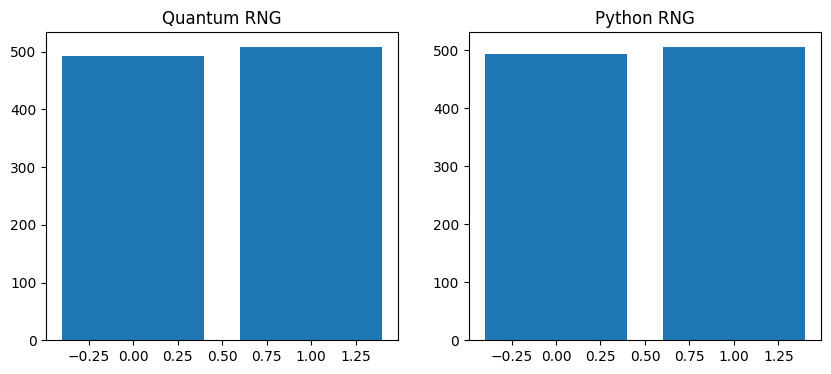

In [ ]:
!pip install -q qiskit qiskit-aer matplotlib

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import random
import matplotlib.pyplot as plt

# Quantum RNG
qc = QuantumCircuit(1,1)
qc.h(0)
qc.measure(0,0)

simulator = AerSimulator()

quantum_results = []

for _ in range(1000):
    job = simulator.run(qc, shots=1)
    result = job.result()
    counts = result.get_counts()
    quantum_results.append(int(list(counts.keys())[0]))

# Python RNG
python_results = [random.randint(0,1) for _ in range(1000)]

# Plot comparison
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(quantum_results, bins=[-0.5,0.5,1.5], rwidth=0.8)
plt.title("Quantum RNG")

plt.subplot(1,2,2)
plt.hist(python_results, bins=[-0.5,0.5,1.5], rwidth=0.8)
plt.title("Python RNG")

plt.show()

In [ ]:
!pip install -q qiskit qiskit-aer matplotlib

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

qc = QuantumCircuit(1,1)
qc.h(0)
qc.measure(0,0)

sim = AerSimulator()

job = sim.run(qc, shots=1024)
result = job.result()

counts = result.get_counts()

print(counts)

plot_histogram(counts)
plt.show()

{'0': 523, '1': 501}
